# Taller de Aprendizaje No Supervisado
## Parte 2: Segmentación de Clientes de Tarjeta de Crédito (variables numéricas)

### Credit Card Dataset

[Credit Card Dataset for Clustering](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata)

Resume el comportamiento de uso de unos **9.000 titulares** de tarjeta durante los últimos 6 meses, con **17 variables numéricas de comportamiento** (saldo, compras, adelantos de efectivo, límite de crédito, pagos...).

> **Diferencia clave con el dataset de setas:** aquí **no hay etiqueta**. El objetivo *es* encontrar segmentos de clientes para definir una estrategia de marketing. Esto es aprendizaje no supervisado «de verdad»: no podemos calcular ARI porque no hay verdad de referencia; nos guiamos por métricas internas y por la **interpretabilidad** de los segmentos.

Además, al ser numérico y con escalas muy distintas, aparecen dos pasos que con las setas no hicieron falta: **imputar nulos** y **escalar**.

In [34]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
# Importad el resto a medida que los necesiteis (TSNE, GMM, DBSCAN, metricas...)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

### Leer conjunto de datos y primer vistazo

In [2]:
# Leer el csv (esta en 'data/credit_card.csv') y mostrar las primeras filas.
df = pd.read_csv("data/credit_card.csv")
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### Exploración de datos

In [3]:
# Tamano del dataset.
df.shape

(8950, 18)

In [4]:
# Descripcion estadistica. Fijaos en las escalas tan distintas entre variables.
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [5]:
# Tipos de datos.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

#### Nulos

In [6]:
# Contar nulos por variable (mostrad solo las que tengan).
nulos = df.isnull().sum()
nulos[nulos > 0]

CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Hay nulos en `CREDIT_LIMIT` (1) y `MINIMUM_PAYMENTS` (~313). Al ser variables numéricas muy sesgadas, los imputamos con la **mediana** (más robusta que la media).

In [7]:
# 1. Eliminar CUST_ID (es un identificador)
df = df.drop(columns=['CUST_ID'])
# 2. Imputar los nulos con la mediana de cada columna
df = df.fillna(df.median())

#### Distribución de algunas variables

Muchas variables están **muy sesgadas** (la mayoría de clientes gasta poco y unos pocos muchísimo). Esto es típico en datos financieros.

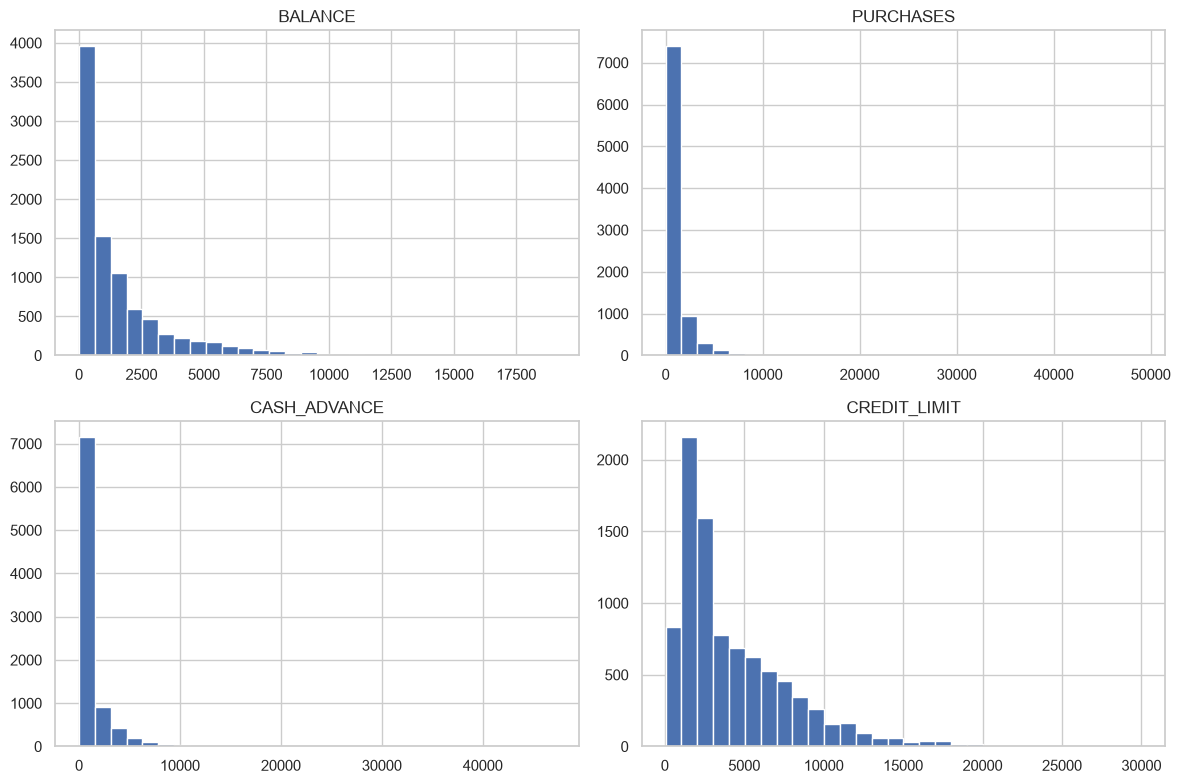

In [8]:
# Pintar histogramas de unas cuantas variables (df[cols].hist...) y observar el sesgo.
cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']
df[cols].hist(bins=30, figsize=(12, 8))
plt.tight_layout() 
plt.show()

### Escalado

K-Means, PCA y casi todos los algoritmos de distancia son **sensibles a la escala**. `CREDIT_LIMIT` llega a miles y `PURCHASES_FREQUENCY` está entre 0 y 1: sin escalar, las variables grandes dominarían. Estandarizamos (media 0, desviación 1).

In [9]:
# Aplicar StandardScaler a df -> X (array escalado)
scaler = StandardScaler()
X = scaler.fit_transform(df)

## PCA

Con 17 variables no podemos pintar un scatter directo. Usamos PCA para (1) ver cuánta información retiene cada componente y (2) proyectar a 2D.

Varianza explicada por cada componente:
[2.72976713e-01 2.03137796e-01 8.81318170e-02 7.47952439e-02
 6.22472925e-02 5.74005645e-02 4.88342555e-02 4.29920325e-02
 3.79825870e-02 3.08000227e-02 2.37225104e-02 1.77336964e-02
 1.42785685e-02 1.21691956e-02 1.01266703e-02 2.67034839e-03
 6.85226796e-07]


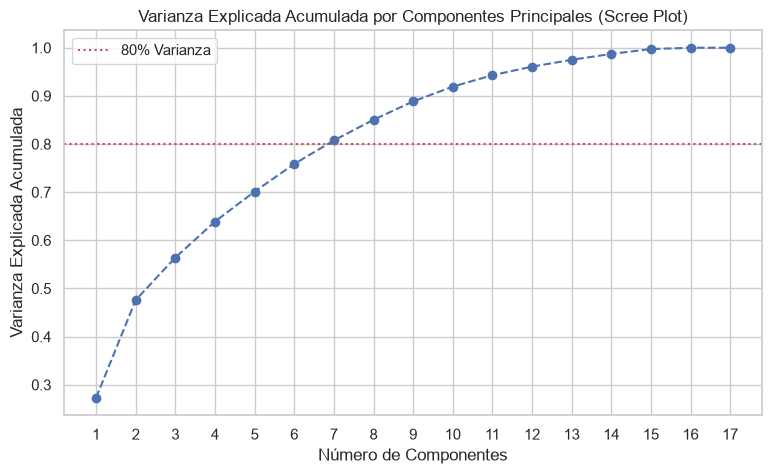

Número de componentes necesarias para alcanzar el ~80% de varianza: 7


In [10]:
# 1. Ajustar PCA sin fijar n_components y mirar explained_variance_ratio_
pca = PCA()
pca.fit(X)

print("Varianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

# 2. Pintar la varianza explicada acumulada (scree plot)
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o', linestyle='--')
plt.axhline(y=0.80, color='r', linestyle=':', label='80% Varianza')

plt.title('Varianza Explicada Acumulada por Componentes Principales (Scree Plot)')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.xticks(range(1, len(varianza_acumulada) + 1))
plt.grid(True)
plt.legend()
plt.show()

# 3. Decidir cuantas componentes hacen falta para ~80% de varianza
componentes_80 = np.argmax(varianza_acumulada >= 0.80) + 1
print(f"Número de componentes necesarias para alcanzar el ~80% de varianza: {componentes_80}")

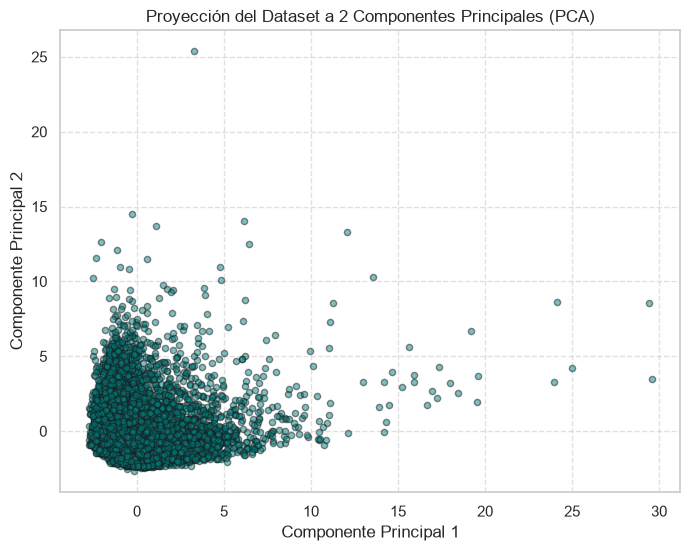

In [11]:
# Proyectar X a 2 componentes y pintar el scatter (aun sin colores: no hay etiqueta)
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, color='teal', edgecolor='k', s=20)

plt.title('Proyección del Dataset a 2 Componentes Principales (PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

A diferencia de las setas, aquí no vemos grupos separados a simple vista: es más bien una **nube continua**. El clustering nos ayudará a trazar fronteras útiles dentro de ella.

## Clustering: ¿cuántos segmentos? Codo + Silhouette

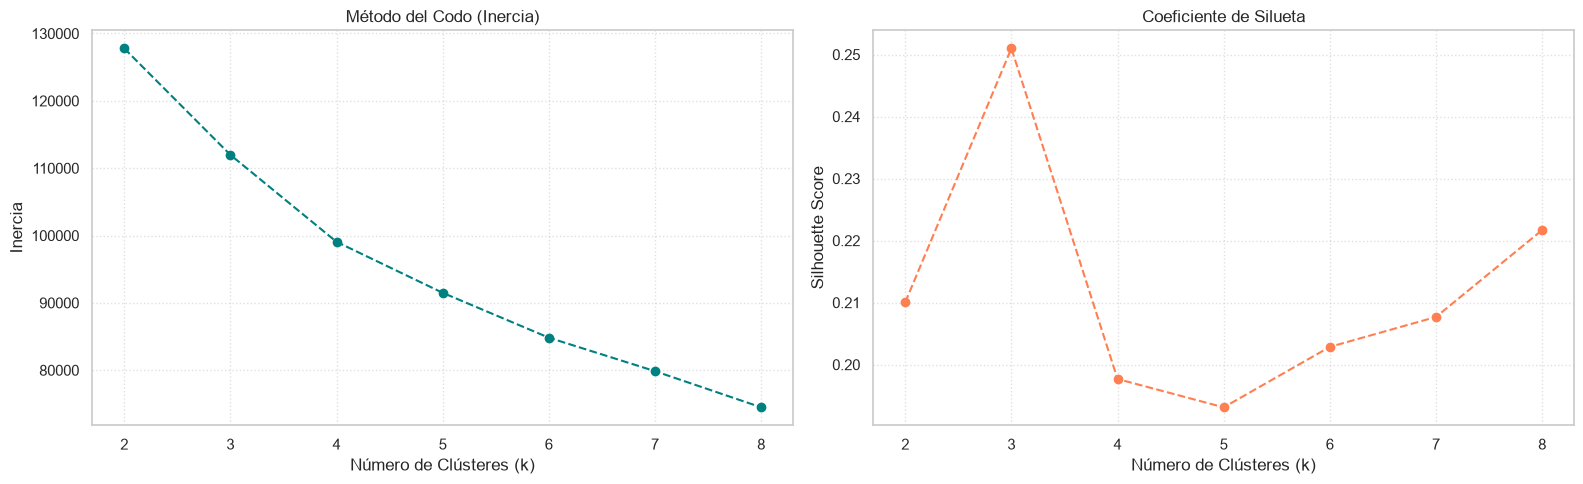

El mejor número de clústeres según la silueta es: 3


In [ ]:
k_values = range(2, 9)
inercias, silhouettes = [], []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    
    inercias.append(kmeans.inertia_)
    
    score = silhouette_score(X, kmeans.labels_)
    silhouettes.append(score)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(k_values, inercias, marker='o', color='teal', linestyle='--')
ax1.set_title('Método del Codo (Inercia)')
ax1.set_xlabel('Número de Clústeres (k)')
ax1.set_ylabel('Inercia')
ax1.set_xticks(k_values)
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.plot(k_values, silhouettes, marker='o', color='coral', linestyle='--')
ax2.set_title('Coeficiente de Silueta')
ax2.set_xlabel('Número de Clústeres (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_values)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

best_k = list(k_values)[silhouettes.index(max(silhouettes))]
print(f"El mejor número de clústeres según la silueta es: {best_k}")

### K-Means final

In [16]:
# Entrenar KMeans con best_k, guardar las etiquetas y mirar el tamano de cada cluster
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_final.fit(X)
df['cluster'] = kmeans_final.labels_
print("Tamaño de cada clúster (número de clientes):")
print(df['cluster'].value_counts().sort_index())

Tamaño de cada clúster (número de clientes):
cluster
0    1275
1    6114
2    1561
Name: count, dtype: int64


### Comparativa de algoritmos

Sin etiqueta, comparamos con **métricas internas**: *silhouette* y *Calinski-Harabasz* (más alto = mejor) y *Davies-Bouldin* (más bajo = mejor).

In [18]:
# Definir evaluar(nombre, labels, X) con silhouette, davies_bouldin y calinski_harabasz
# (sin ARI: no hay etiqueta). Comparar KMeans, Aglomerativo y GMM.
# 1. Definir la función evaluar(nombre, labels, X)
resultados = []

def evaluar(nombre, labels, X):
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    
    resultados.append({
        'Algoritmo': nombre,
        'Silhouette (↑)': sil,
        'Davies-Bouldin (↓)': db,
        'Calinski-Harabasz (↑)': ch
    })
    print(f"[{nombre}] Evaluado con éxito.")

evaluar('KMeans', kmeans_final.labels_, X)


agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X)
evaluar('Aglomerativo', agg_labels, X)

gmm = GaussianMixture(n_components=3, random_state=42, n_init=5)
gmm_labels = gmm.fit_predict(X)
evaluar('GMM', gmm_labels, X)


df_comparativa = pd.DataFrame(resultados)
df_comparativa

[KMeans] Evaluado con éxito.
[Aglomerativo] Evaluado con éxito.
[GMM] Evaluado con éxito.


,Algoritmo,Silhouette (↑),Davies-Bouldin (↓),Calinski-Harabasz (↑)
0,KMeans,0.250988,1.591959,1605.026358
1,Aglomerativo,0.167447,1.849565,1239.325647
2,GMM,0.110460,2.651496,903.740735


### Dendrograma

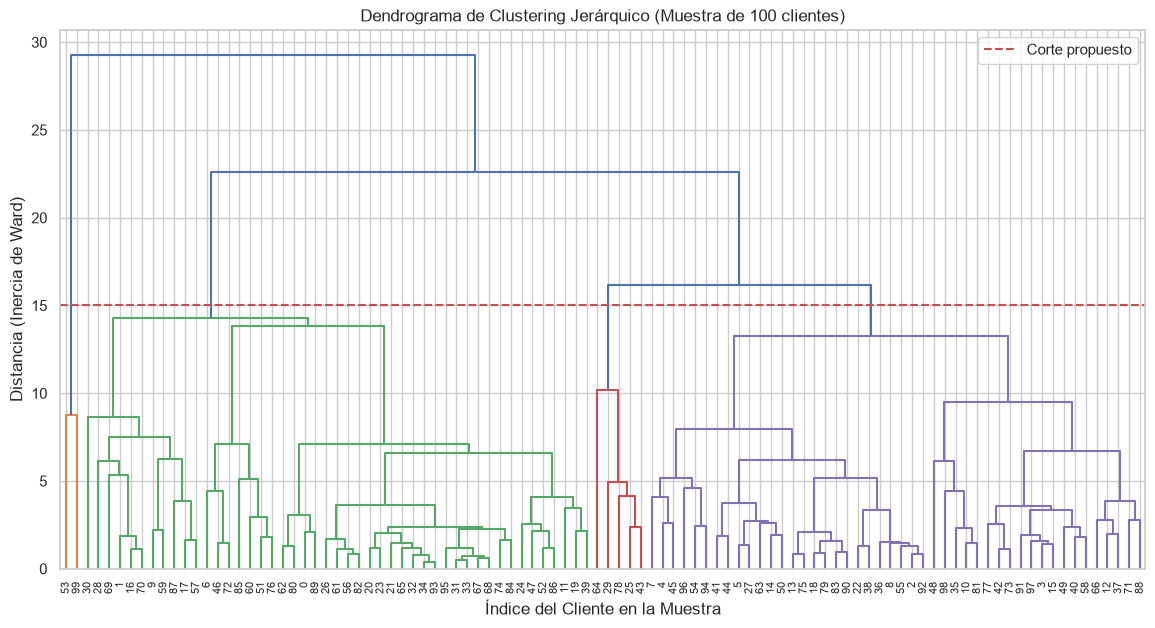

In [20]:
# linkage + dendrogram sobre una muestra de X
np.random.seed(42)
indices_muestra = np.random.choice(X.shape[0], size=100, replace=False)
X_muestra = X[indices_muestra]

Z = linkage(X_muestra, method='ward')

plt.figure(figsize=(14, 7))
dendrogram(
    Z,
    leaf_rotation=90.,  
    leaf_font_size=8.,   
    color_threshold=15  
)

plt.title('Dendrograma de Clustering Jerárquico (Muestra de 100 clientes)')
plt.xlabel('Índice del Cliente en la Muestra')
plt.ylabel('Distancia (Inercia de Ward)')
plt.axhline(y=15, color='r', linestyle='--', label='Corte propuesto')
plt.legend()
plt.show()

### DBSCAN: ¿hay clusters de densidad aquí?

Probamos DBSCAN. Veréis que en alta dimensión tiende a juntar casi todo en **un solo cluster** y marcar el resto como **ruido**. Eso nos dice algo importante: estos datos son una nube continua, no grupos separados por densidad. Aquí DBSCAN funciona mejor como **detector de atípicos** que como segmentador.

In [22]:
# Ejecutar DBSCAN sobre la proyeccion PCA(2). Observar cuantos clusters y cuanto ruido.
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_pca)

valores_unicos, conteos = np.unique(dbscan_labels, return_counts=True)

print("Resultados de DBSCAN:")
for val, count in zip(valores_unicos, conteos):
    if val == -1:
        print(f"  Ruido (puntos atípicos): {count} puntos")
    else:
        print(f"  Clúster {val}: {count} puntos")

Resultados de DBSCAN:
  Ruido (puntos atípicos): 134 puntos
  Clúster 0: 8790 puntos
  Clúster 1: 8 puntos
  Clúster 2: 6 puntos
  Clúster 3: 6 puntos
  Clúster 4: 6 puntos


### Visualización de los segmentos (t-SNE)

Proyectamos con t-SNE (sobre una muestra) y coloreamos por el segmento de K-Means.

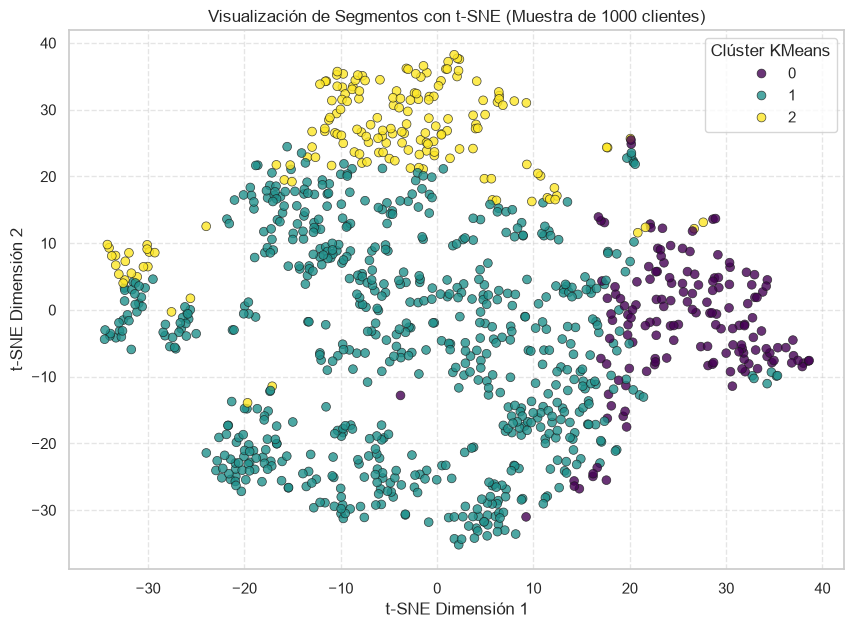

In [ ]:
# t-SNE sobre una muestra de X, coloreado por el cluster de KMeans
np.random.seed(42)
indices_tsne = np.random.choice(X.shape[0], size=1000, replace=False)

X_muestra_tsne = X[indices_tsne]
labels_muestra_tsne = df['cluster'].iloc[indices_tsne]

tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_muestra_tsne)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=labels_muestra_tsne,
    palette='viridis',
    alpha=0.8,
    edgecolor='k',
    s=40
)

plt.title('Visualización de Segmentos con t-SNE (Muestra de 1000 clientes)')
plt.xlabel('t-SNE Dimensión 1')
plt.ylabel('t-SNE Dimensión 2')
plt.legend(title='Clúster KMeans')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Interpretación de los segmentos

Lo más importante en segmentación: **¿qué caracteriza a cada grupo?** Calculamos la media de cada variable por cluster y la estandarizamos entre clusters (rojo = por encima de la media, azul = por debajo). Así leemos el «perfil» de cada segmento.

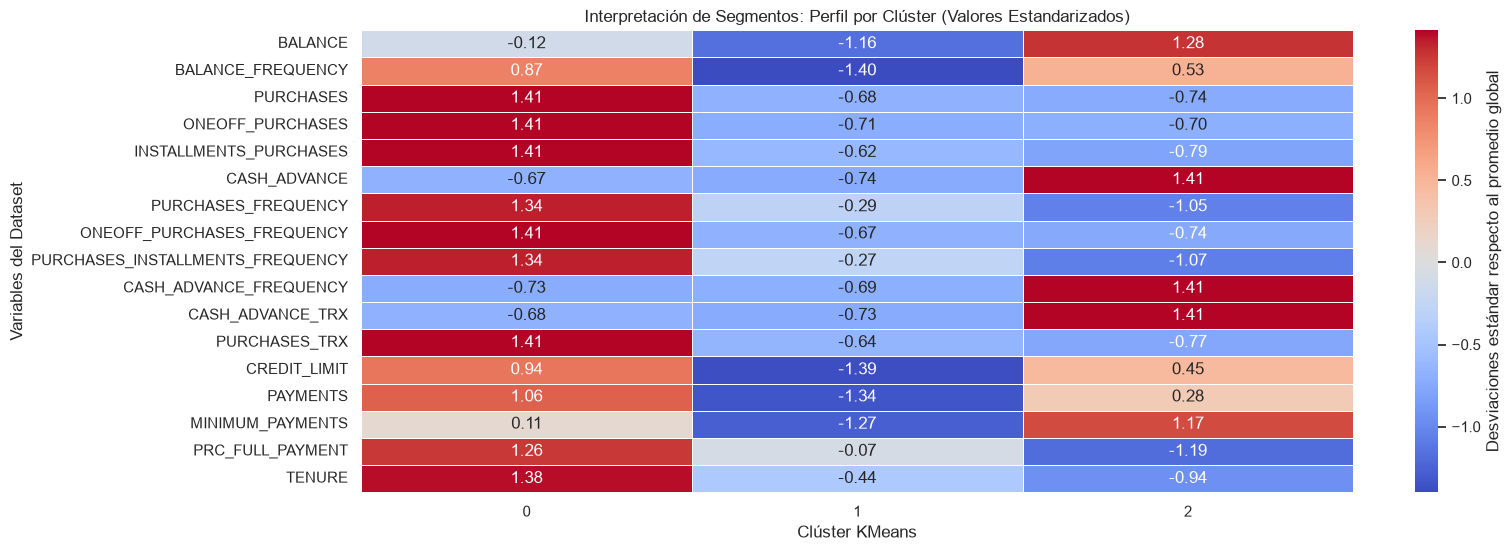

In [28]:
# 1. Anadir la columna 'cluster' al df original (sin escalar)
# 2. Calcular la media de cada variable por cluster
# 3. Estandarizar entre clusters y pintar un heatmap (perfil de cada segmento)

perfil_medias = df.groupby('cluster').mean()

scaler_perfil = StandardScaler()
perfil_escalado = pd.DataFrame(
    scaler_perfil.fit_transform(perfil_medias),
    columns=perfil_medias.columns,
    index=perfil_medias.index
)

plt.figure(figsize=(16, 6))
sns.heatmap(
    perfil_escalado.T,  
    annot=True,        
    fmt=".2f",          
    cmap="coolwarm",    
    linewidths=0.5,
    cbar_kws={'label': 'Desviaciones estándar respecto al promedio global'}
)

plt.title('Interpretación de Segmentos: Perfil por Clúster (Valores Estandarizados)')
plt.xlabel('Clúster KMeans')
plt.ylabel('Variables del Dataset')
plt.show()

Leyendo el heatmap se pueden nombrar los segmentos en términos de **negocio**, por ejemplo: clientes de alto saldo y muchas compras (VIP), clientes que tiran de adelantos de efectivo (riesgo), clientes poco activos, etc. Ese nombre y la estrategia asociada es justo el entregable que pide el caso.

## Detección de anomalías (Isolation Forest)

Identificamos los clientes con comportamiento más atípico (posible fraude, errores de datos o clientes premium fuera de norma).

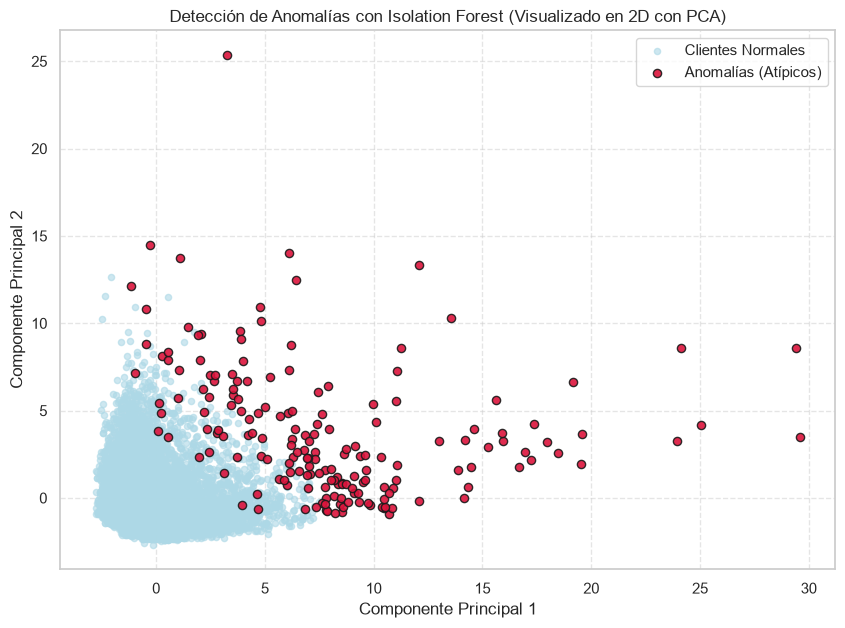

Número de anomalías detectadas: 179 de 8950 clientes.


In [30]:
# IsolationForest sobre X, marcar los atipicos (-1) y pintarlos sobre PCA(2)
iforest = IsolationForest(contamination=0.02, random_state=42)
iforest_labels = iforest.fit_predict(X)

df['anomaly_iforest'] = iforest_labels


plt.figure(figsize=(10, 7))


plt.scatter(
    X_pca[iforest_labels == 1, 0], X_pca[iforest_labels == 1, 1],
    c='lightblue', alpha=0.6, label='Clientes Normales', s=20
)


plt.scatter(
    X_pca[iforest_labels == -1, 0], X_pca[iforest_labels == -1, 1],
    c='crimson', alpha=0.9, label='Anomalías (Atípicos)', s=35, edgecolor='k'
)

plt.title('Detección de Anomalías con Isolation Forest (Visualizado en 2D con PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


conteo_anomalias = (iforest_labels == -1).sum()
print(f"Número de anomalías detectadas: {conteo_anomalias} de {X.shape[0]} clientes.")

In [31]:
# 1. Crear el ratio de uso del límite de crédito (evitando división por cero)
df['LIMIT_USAGE_RATIO'] = np.where(
    df['CREDIT_LIMIT'] > 0, 
    df['BALANCE'] / df['CREDIT_LIMIT'], 
    0
)

# 2. Crear la compra media por transacción (evitando división por cero)
df['AVG_PURCHASE_PER_TRX'] = np.where(
    df['PURCHASES_TRX'] > 0, 
    df['PURCHASES'] / df['PURCHASES_TRX'], 
    0
)

# 3. Crear el avance de efectivo medio por transacción (opcional, muy útil para el Clúster 2)
df['AVG_CASH_ADVANCE_PER_TRX'] = np.where(
    df['CASH_ADVANCE_TRX'] > 0, 
    df['CASH_ADVANCE'] / df['CASH_ADVANCE_TRX'], 
    0
)

# Verificar los nuevos KPIs creados
df[['LIMIT_USAGE_RATIO', 'AVG_PURCHASE_PER_TRX', 'AVG_CASH_ADVANCE_PER_TRX']].head()

,LIMIT_USAGE_RATIO,AVG_PURCHASE_PER_TRX,AVG_CASH_ADVANCE_PER_TRX
0,0.040901,47.700000,0.000000
1,0.457495,0.000000,1610.736371
2,0.332687,64.430833,0.000000
3,0.222223,1499.000000,205.788017
4,0.681429,16.000000,0.000000


---
## Para ir más allá (opcional)

- **Ingeniería de KPIs**: derivar variables como *ratio de uso del límite* (`BALANCE / CREDIT_LIMIT`) o *compra media por transacción* suele mejorar mucho los segmentos.
- **UMAP / HDBSCAN** para visualización y clustering por densidad más robusto.
- **Transformación logarítmica** de las variables sesgadas antes de escalar.

## Conclusiones

- Sin etiqueta, la segmentación se valida con métricas internas (*silhouette*, etc.) y, sobre todo, con la **interpretabilidad** de los perfiles.
- Imputar y **escalar** fue imprescindible aquí (a diferencia de las setas).
- K-Means, GMM y Aglomerativo dan segmentos coherentes; DBSCAN reveló que los datos son una nube continua (mejor como detector de atípicos).
- El heatmap de perfiles convierte los clusters en **segmentos de negocio accionables**.